# Global Conflict Early Warning System Using ACLED Data
## Objective
To build a global conflict early warning system that uses ACLED data, risk scores, and anomaly detection to identify emerging instability and conflict escalation trends.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

from statsmodels.tsa.arima.model import ARIMA

# Dataset Overview
Source:
- Armed Conflict Location & Event Data (ACLED)

Region:
- Middle East

Years Analyzed:
- December 2014 - May 2026

Focus Areas:
- Conflcit Frequency
- Fatalities
- Event Types
- Regional Escalation Trends

In [2]:
acled_data = pd.read_excel("../data/acled_middle_east.xlsx")

# Data Cleaning & Standardization
This section prepares and standardizes the dataset for exploratory conflict analysis and visualization.

In [3]:
acled_data.columns = acled_data.columns.str.lower().str.replace(" ", "_")
acled_data['week'] = pd.to_datetime(acled_data['week'])

In [4]:
acled_data['fatalities'] = acled_data['fatalities'].fillna(0)

In [5]:
acled_data['year'] = acled_data['week'].dt.year
acled_data['month'] = acled_data['week'].dt.to_period('M')

# Create Country-Level Time Series & Pivot
This section restructures ACLED data into a monthly time series and pivot table.

In [6]:
country_monthly = acled_data.groupby(['country', 'month']).size().reset_index(name='event_count')
country_monthly['month'] = country_monthly['month'].astype(str)

pivot = country_monthly.pivot(index='month', columns='country', values='event_count').fillna(0)

# Anomaly Detection & Flagging High-Risk Months
Here anomaly scores are created and high risk months are labeled.

In [7]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(pivot)

model = IsolationForest(contamination=0.05, random_state=42)
model.fit(scaled)

anomaly_scores = model.decision_function(scaled)
anomalies = model.predict(scaled)

results = pd.DataFrame({
    "month": pivot.index,
    "anomaly_score" : anomaly_scores,
    "anomaly_flag" : anomalies
})

results['risk_level'] = np.where(results['anomaly_flag'] == -1, "HIGH RISK", "NORMAL")

# Generate & Normalize Country Risk Score
In this section a country risk score is created and normalized from 0-1.

In [8]:
country_risk = acled_data.groupby('country').agg({
    'fatalities':'sum',
    'week':'count'
}).rename(columns={'week':'events'})

country_risk['risk_score'] = (
    country_risk['fatalities'] * 0.7 +
    country_risk['events'] * 0.3
)

country_risk = country_risk.sort_values('risk_score', ascending=False)

country_risk['risk_score_norm'] = (
    country_risk['risk_score'] - country_risk['risk_score'].min()
) / (country_risk['risk_score'].max() - country_risk['risk_score'].min())

# Forecast
Data is separated into train and test groups and forecasted.

In [9]:
monthly_global = acled_data.groupby('month').size()
monthly_global.index = monthly_global.index.to_timestamp()

train = monthly_global[:-6]
test = monthly_global[-6:]

model_arima = ARIMA(train, order=(2,1,2))
model_fit = model_arima.fit()
forecast = model_fit.forecast(steps=6)

# Dual Visualization
These visualizations highlight the number of global conflicts over time and the top 10 highest risk scores.

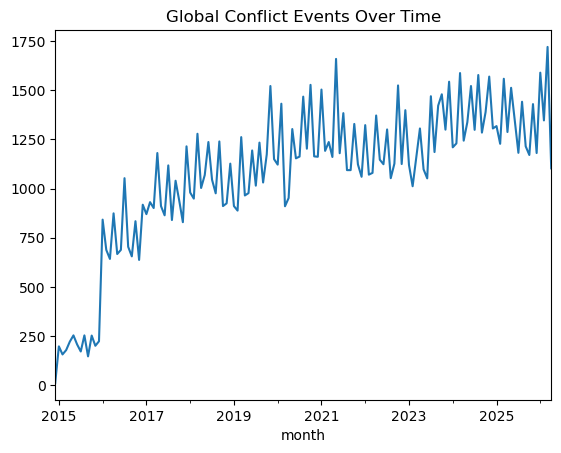

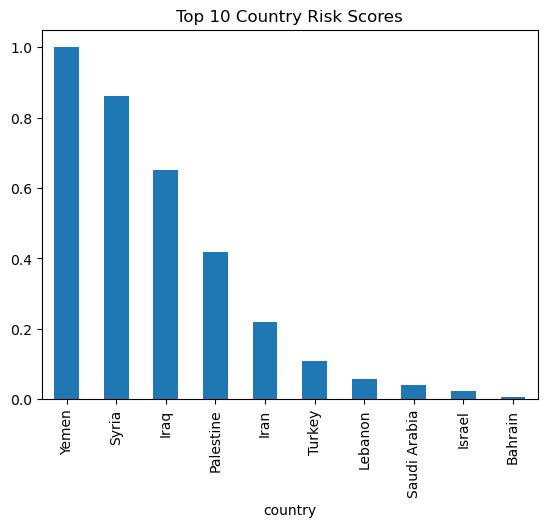

In [10]:
plt.figure()
monthly_global.plot(title = "Global Conflict Events Over Time")
plt.show()

plt.figure()
country_risk['risk_score_norm'].head(10).plot(kind='bar', title="Top 10 Country Risk Scores")
plt.show()

## Key Findings
* Global conflicts in 2016 rose from 250 to 850 global conflict events.
* Steady increase overtime in global conflict events since 2016.
* Yemen lands the highest risk score of the countries tested.

## Intelligence Implications
* Pattern of continued unrest in the Middle East driven by proxy conflicts or insurgent activity.
* 2016 increase aligns to escalation in the Syrian Civil War or expansion of the Islamic State
* Yemen's 1.00 risk score reflects the ongoing security crises and conflcit involving the Houthi Movement.

# Output Intelligence Tables and Export CSVs
Both the High Risk Period and Top Risk Countries tables are displayed and exported.

In [11]:
print("\n=== HIGH RISK PERIODS ===")
print(results[results['risk_level']=='HIGH RISK'])

print("\n=== TOP RISK COUNTRIES ===")
print(country_risk.head(10))

results.to_csv("anomaly_detection_results.csv", index=False)
country_risk.to_csv("country_risk_scores.csv")

print("Pipeline complete: Early Warning System generated.")


=== HIGH RISK PERIODS ===
       month  anomaly_score  anomaly_flag risk_level
0    2014-12      -0.036744            -1  HIGH RISK
12   2015-12      -0.029190            -1  HIGH RISK
77   2021-05      -0.073474            -1  HIGH RISK
106  2023-10      -0.004325            -1  HIGH RISK
134  2026-02      -0.096466            -1  HIGH RISK
135  2026-03      -0.208812            -1  HIGH RISK
136  2026-04      -0.054800            -1  HIGH RISK

=== TOP RISK COUNTRIES ===
              fatalities  events  risk_score  risk_score_norm
country                                                      
Yemen             167198   31295    126427.1         1.000000
Syria             143205   28916    108918.3         0.861472
Iraq              107726   22829     82256.9         0.650531
Palestine          72452    7368     52926.8         0.418474
Iran               33686   13577     27653.3         0.218513
Turkey              9711   22930     13676.7         0.107932
Lebanon             7295 